# İKY Kitaplarının İçindekiler Sayfalarıyla *hrdergi.com* Makalelerinin Analizi

**Amaç:** 8 adet İnsan Kaynakları Yönetimi ders kitabının *İçindekiler* sayfalarından alan "kavram haritası" çıkarmak ve bu haritayı `hrdergi_korpus_final.csv` içindeki **Makale İçeriği** sütunundaki ~3.900 makaleye uygulamak.

**Akış**
1. Veri yükleme ve temizlik
2. Kitap txt dosyalarından içindekiler (İÇ) bloğunu çıkarma ve başlıkları ayrıştırma
3. İÇ'ten türetilen (a) konu sözlüğü ve (b) konsensüs kavramlar
4. Makale metinlerinin ön işlemesi
5. Konu/kavram yaygınlığı: genel, yıllara/dönemlere göre
6. İÇ başlıkları ↔ makaleler eşleştirmesi (TF-IDF kosinüs): hangi kitap konuları dergide ne kadar işleniyor?
7. Denetimsiz konu modeli (NMF) ve İÇ konularıyla karşılaştırma
8. Dışa aktarım (Excel + grafikler)

> **Not:** Kitapların OCR çıktılarında bozuk karakterler (`Ġ`→`İ`, `ġ`→`Ş`, `Ģ`→`ş`) ve düzensiz biçim vardır. İçindekiler satır aralıkları aşağıdaki `BOOKS` tablosunda **elle düzenlenebilir**. `0` numaralı kitabın (4 KB) içindekiler sayfası boş olduğundan atlanır.

## 0. Kurulum ve yollar

In [1]:
# Colab'da gerekirse: !pip -q install pandas scikit-learn matplotlib openpyxl
import os, re, glob, zipfile, unicodedata, warnings
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90, "display.width", 160)

# ---- YOLLAR: kendi ortamınıza göre değiştirin ----
ARCHIVE_ZIP = "Archive.zip"                      # kitap txt dosyaları
CSV_ZIP     = "hrdergi_korpus_final.csv.zip"     # makale korpusu (veya doğrudan .csv)
WORK_DIR    = "work"                             # açılan dosyalar ve çıktılar
os.makedirs(WORK_DIR, exist_ok=True)

def unzip(path, dest):
    # Zip içindeki dosya adları (macOS) bozuk kodlanmış olabilir: adı onar, kısalt, NFC'ye çevir
    if not os.path.exists(path):
        return
    os.makedirs(dest, exist_ok=True)
    with zipfile.ZipFile(path) as z:
        for zi in z.infolist():
            if zi.is_dir() or "__MACOSX" in zi.filename:
                continue
            name = zi.filename
            if not (zi.flag_bits & 0x800):                       # UTF-8 bayrağı yoksa cp437 okunmuştur
                try: name = name.encode("cp437").decode("utf-8")
                except Exception: pass
            name = unicodedata.normalize("NFC", os.path.basename(name))
            stem, ext = os.path.splitext(name)
            while len(stem.encode("utf-8")) > 180: stem = stem[:-1]   # dosya sistemi sınırı için kısalt
            name = stem + ext
            with z.open(zi) as src, open(os.path.join(dest, name), "wb") as dst:
                dst.write(src.read())
unzip(ARCHIVE_ZIP, f"{WORK_DIR}/books")
unzip(CSV_ZIP, f"{WORK_DIR}/csv")

# __MACOSX gibi meta klasörleri dışla; dosya adlarını sıralı al
BOOK_FILES = sorted(p for p in glob.glob(f"{WORK_DIR}/books/**/*.txt", recursive=True) if "__MACOSX" not in p)
CSV_PATH = next(p for p in glob.glob(f"{WORK_DIR}/csv/**/*.csv", recursive=True) if "__MACOSX" not in p) \
           if glob.glob(f"{WORK_DIR}/csv/**/*.csv", recursive=True) else "hrdergi_korpus_final.csv"
print(len(BOOK_FILES), "kitap dosyası;", "CSV:", CSV_PATH)

8 kitap dosyası; CSV: work/csv/hrdergi_korpus_final.csv


## 1. Makale korpusunu yükleme ve temizlik

In [2]:
df = pd.read_csv(CSV_PATH)
TEXT = "Makale İçeriği"
print(df.shape); print(df.columns.tolist())

df[TEXT] = df[TEXT].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
n0 = len(df)
df = df.drop_duplicates(subset=["Makale Başlığı", TEXT]).reset_index(drop=True)
df["Yıl"] = pd.to_numeric(df["Yıl"], errors="coerce").astype("Int64")
df["uzunluk"] = df[TEXT].str.len()
print(f"Yinelenen kayıt: {n0-len(df)} | Makale sayısı: {len(df)}")
display(df["uzunluk"].describe().round(0))
display(df.groupby("Yıl").size().rename("makale").to_frame().T)

(3932, 5)
['Yıl', 'Ay', 'Makale Başlığı', 'Makale İçeriği', 'URL']


Yinelenen kayıt: 0 | Makale sayısı: 3932


count     3932.0
mean     10205.0
std       6975.0
min        280.0
25%       5680.0
50%       8608.0
75%      12610.0
max      57668.0
Name: uzunluk, dtype: float64

Yıl,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
makale,137,65,70,115,101,107,102,101,117,132,...,119,139,134,154,186,191,234,222,217,196


## 2. Kitaplardan İçindekiler bloğunu çıkarma

Her kitap için içindekiler bloğunun `(başlangıç, bitiş)` satırı verilir (0 tabanlı). Bunlar dosyalar incelenerek belirlenmiştir; farklı baskı kullanırsanız burayı güncelleyin.

In [3]:
# dosya sırası = sorted(BOOK_FILES) sırası. (None, None) -> içindekiler yok/boş, atla.
def tr_lower(s):
    return s.replace("İ", "i").replace("I", "ı").lower()

BOOKS = {
    0: dict(ad="İKY (Bingöl, 8. bs.)",             start=None, end=None),   # yalnızca 4 KB, içindekiler boş
    1: dict(ad="İKY (Tüzüner vd., 2023, Beta)",    start=262,  end=1761),
    2: dict(ad="İKY (Çetin-Dinç Elmalı-Arslan, 2019)", start=207, end=1227),
    3: dict(ad="İKY (Bakan, 2014, Gazi)",          start=235,  end=1042),
    4: dict(ad="İKY (Saruhan-Yıldız, 2019, Beta)", start=75,   end=222),
    5: dict(ad="İKY Yoluyla... (Keçecioğlu, 2012)",start=63,   end=100),
    6: dict(ad="Stratejik İKY (Bayraktaroğlu-Atay, 2016)", start=142, end=444),
    7: dict(ad="İKY ve Kariyer (Şimşek vd., 2016)",start=259,  end=470),
}
assert len(BOOK_FILES) >= len(BOOKS), "Kitap dosyası sayısı beklenenden az"
# Dosya adından kitap eşleme (sıra bağımlılığını kaldırır). Anahtar: ad içinde geçen ayırt edici sözcük
KEYS = {0: "Bilinmeyen", 1: "TÜZÜNER", 2: "ÇETİN", 3: "Bakan", 4: "SARUHAN", 5: "Keçecioğlu", 6: "BAYRAKTAROGLU", 7: "Şimşek"}
def find_book(key):
    k = tr_lower(unicodedata.normalize("NFC", key))
    hits = [p for p in BOOK_FILES if k in tr_lower(unicodedata.normalize("NFC", os.path.basename(p)))]
    assert hits, f"Dosya bulunamadı: {key}"
    return hits[0]

def read_lines(path):
    with open(path, encoding="utf-8", errors="replace") as f:
        return f.read().split("\n")

# OCR/yazı tipi kaynaklı bozuk karakter düzeltmesi
FIX = str.maketrans({"Ġ": "İ", "ġ": "Ş", "Ģ": "ş"})
def fix_chars(s): return unicodedata.normalize("NFC", s.translate(FIX))

toc_raw = []
for i, meta in BOOKS.items():
    if meta["start"] is None:
        print(f"[atlandı] {i}: {meta['ad']}"); continue
    L = read_lines(find_book(KEYS[i]))[meta["start"]:meta["end"]]
    toc_raw += [(i, meta["ad"], fix_chars(l)) for l in L if l.strip()]
toc_raw = pd.DataFrame(toc_raw, columns=["kitap_id", "kitap", "satir"])
print(toc_raw.groupby("kitap").size())

[atlandı] 0: İKY (Bingöl, 8. bs.)
kitap
Stratejik İKY (Bayraktaroğlu-Atay, 2016)    152
İKY (Bakan, 2014, Gazi)                     403
İKY (Saruhan-Yıldız, 2019, Beta)             73
İKY (Tüzüner vd., 2023, Beta)               759
İKY (Çetin-Dinç Elmalı-Arslan, 2019)        517
İKY Yoluyla... (Keçecioğlu, 2012)            18
İKY ve Kariyer (Şimşek vd., 2016)           105
dtype: int64


### 2.1 Satırları başlıklara ayrıştırma

In [4]:
def tr_lower(s):
    return s.replace("İ", "i").replace("I", "ı").lower()

LEADER = re.compile(r"[\.…·_\-–]{3,}.*$")          # ..... 15  kuyruğu
TRAIL_PG = re.compile(r"\s+[\divxlcIVXLC]{1,4}(\s*[,-]\s*\d+)*\s*$")  # sondaki sayfa no
LEAD_NUM = re.compile(r"^\s*((\d+\.)+\d*\.?|\(?\d+\)|\(?[A-Za-zÇĞİÖŞÜçğıöşü]{1,3}\s?\)|[A-ZÇĞİÖŞÜ]\.|[IVX]+\.)\s*")   # 1.2. / a) / bf ) / A. / IV.   # 1.2.3. / A. / IV.
CHAP = re.compile(r"^\s*((\d+|[İI]LK|BİRİNCİ|İKİNCİ|ÜÇÜNCÜ|DÖRDÜNCÜ|BEŞİNCİ|ALTINCI|YEDİNCİ|SEKİZİNCİ|DOKUZUNCU|ONUNCU|ON\s?\w+)\.?\s*B[ÖO]L[ÜU]M|B[ÖO]L[ÜU]M\s*\d+|\d+\.\s*B[öo]l[üu]m)\s*$", re.I)
NOISE = re.compile(r"^(şekil|tablo|vaka|okuma parças|kaynakça|kaynaklar|dizin|konu dizini|içindekiler|sayfa no|önsöz|sunuş|teşekkür|giriş$|sonuç$|özet$|kavramlar$|tartışma soruları|test soruları|yazar hakkında|ek \d|prof\.|doç\.|yrd\.|dr\.|arş\.|öğr\.)", re.I)
HDR_ONLY = re.compile(r"^(bölüm|chapter)?\s*\d*$", re.I)

rows, cur_chap = [], defaultdict(lambda: 0)
for r in toc_raw.itertuples(index=False):
    t = r.satir.strip()
    if CHAP.match(t):
        cur_chap[r.kitap_id] += 1; continue
    t = LEADER.sub("", t).strip()
    t = TRAIL_PG.sub("", t).strip()
    t = LEAD_NUM.sub("", t).strip(" .:;,-–")
    if len(t) < 6 or HDR_ONLY.match(t) or NOISE.match(tr_lower(t)): continue
    if len(t.split()) > 25: continue                      # gövde metni sızıntısı
    if re.fullmatch(r"[\W\d_]+", t): continue
    rows.append((r.kitap_id, r.kitap, cur_chap[r.kitap_id], t))

toc = pd.DataFrame(rows, columns=["kitap_id", "kitap", "bolum", "baslik"]).drop_duplicates(["kitap_id", "baslik"]).reset_index(drop=True)
toc["baslik_norm"] = toc["baslik"].map(tr_lower)
print(f"{len(toc)} benzersiz başlık")
display(toc.groupby("kitap").agg(baslik=("baslik", "size"), bolum=("bolum", "max")))
display(toc.sample(15, random_state=1)[["kitap", "bolum", "baslik"]])

1647 benzersiz başlık


,baslik,bolum
kitap,,
"Stratejik İKY (Bayraktaroğlu-Atay, 2016)",128,8
"İKY (Bakan, 2014, Gazi)",337,16
"İKY (Saruhan-Yıldız, 2019, Beta)",58,6
"İKY (Tüzüner vd., 2023, Beta)",639,11
"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",389,12
"İKY Yoluyla... (Keçecioğlu, 2012)",10,0
"İKY ve Kariyer (Şimşek vd., 2016)",86,12


,kitap,bolum,baslik
161,"İKY (Tüzüner vd., 2023, Beta)",4,Eğitim Programının Hazırlanması ve Uygulanması
1475,"Stratejik İKY (Bayraktaroğlu-Atay, 2016)",3,Durumsallık Yaklaşımı
1615,"İKY ve Kariyer (Şimşek vd., 2016)",7,ÖRGÜTLERDE KARİYER YÖNETİMİ
558,"İKY (Tüzüner vd., 2023, Beta)",10,Kıdem Tazminatında Zaman Aşımı ve Faiz
801,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",6,Öz Yönetimli Öğrenim
678,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",2,İnsan Kaynakları Yönetimini Etkileyen Çevre Faktörleri
1068,"İKY (Bakan, 2014, Gazi)",2,FAALİYETSEL FONKSİYONLAR
1082,"İKY (Bakan, 2014, Gazi)",3,Alınması Gereken Faktörler
593,"İKY (Tüzüner vd., 2023, Beta)",10,Toplu Pazarlık ve Toplu İş Sözleşmesi
1016,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",12,İnsan Kaynakları Bilgi Sistemi (İKBS)’nin Tanımı


## 3. İçindekilerden konu sözlüğü

**(a) Konu sözlüğü:** Kitap bölüm/başlık dizilerinde yinelenen İKY işlevleri (işe alma, performans, ücret...) tanımlanmıştır. Her konu için anahtar ifadeler verilir; ardından **kitap başlıklarında gerçekten geçip geçmediği** sınanır (İÇ doğrulaması). Sözlüğü kendi araştırma sorunuza göre düzenleyebilirsiniz.

**(b) Konsensüs kavramlar:** Başlıklardan 1–3'lü sözcük öbekleri çıkarılır; en az 2 farklı kitapta geçenler "çekirdek müfredat" kavramı sayılır.

In [5]:
THEMES = {
 "İş analizi, tasarımı ve tanımı":      ["iş analiz", "iş tanım", "iş tasarım", "iş değerleme", "iş zenginleştir", "iş genişlet", "iş rotasyon", "iş gerekleri", "iş etüd"],
 "İK planlaması":                        ["insan kaynakları planla", "işgücü planla", "iş gücü planla", "norm kadro", "talep tahmin"],
 "İşe alma ve seçme":                    ["işe alım", "işe alma", "personel temini", "personel seçimi", "seçme", "mülakat", "mülakât", "görüşme tekni", "aday", "özgeçmiş", "cv ", "işveren markas", "yerleştirme", "oryantasyon", "işe başlatma", "uyum eğitimi"],
 "Eğitim ve geliştirme":                 ["eğitim ihtiyac", "eğitim ve geliştir", "personel eğitimi", "çalışan eğitimi", "yönetici geliştir", "hizmet içi", "mesleki eğitim", "öğrenen örgüt", "e-öğrenme", "koçluk", "mentor", "mentörlük", "işbaşı eğitim"],
 "Performans yönetimi":                  ["performans", "değerlendirme sistem", "360 derece", "hedeflerle yönetim", "dengeli skor", "kpi", "okr", "geri bildirim"],
 "Ücret ve ödül yönetimi":               ["ücret", "maaş", "ödül", "prim", "yan ödeme", "yan hak", "teşvik", "tazminat", "zam ", "bordro", "performansa dayalı ödeme", "esnek ödeme"],
 "Kariyer yönetimi":                     ["kariyer", "terfi", "yükselme", "yedekleme", "halef", "kariyer planla"],
 "Yetenek ve yetkinlik yönetimi":        ["yetenek yönetim", "yetenek savaş", "yetkinlik", "yetenek havuz", "yüksek potansiyel", "talent"],
 "İş sağlığı ve güvenliği":              ["iş sağlığı", "iş güvenliği", "isg", "iş kazası", "meslek hastalığı", "ergonomi", "mobbing", "psikolojik taciz", "stres", "tükenmişlik"],
 "Endüstri ilişkileri ve sendika":       ["sendika", "toplu iş sözleşmesi", "toplu pazarlık", "grev", "lokavt", "endüstri ilişkileri", "çalışma ilişkileri", "iş hukuku", "iş kanunu", "4857", "kıdem tazminat", "işten çıkarma", "işten çıkar", "iş güvencesi", "arabulucu"],
 "Motivasyon, bağlılık ve iş tatmini":   ["motivasyon", "iş tatmini", "iş doyumu", "örgütsel bağlılık", "duygusal bağlılık", "çalışan bağlılığı", "işe bağlılık", "iş yaşam kalitesi", "iş-yaşam dengesi", "çalışan memnuniyet", "çalışan deneyimi", "çalışan katılım", "ödüllendirme"],
 "Örgüt kültürü ve iklimi":              ["örgüt kültür", "örgütsel kültür", "kurum kültür", "örgüt iklimi", "örgütsel iklim", "değerler", "etik"],
 "Liderlik ve yöneticilik":              ["liderlik", "lider ", "yönetici gelişim", "dönüşümcü", "etkileşimci"],
 "Stratejik İKY":                        ["stratejik insan kaynak", "stratejik iky", "stratejik yönetim", "stratejik uyum", "rekabet üstünlüğü", "rekabet avantaj", "kaynak temelli", "kaynak tabanlı", "insan sermayesi", "entelektüel sermaye", "ik skor"],
 "Uluslararası ve küresel İKY":          ["uluslararası insan kaynak", "küresel insan kaynak", "ekspatriye", "expatriate", "uluslararası", "küreselleş", "çok uluslu", "kültürlerarası"],
 "Çeşitlilik, kapsayıcılık, cinsiyet":   ["çeşitlilik", "farklılıkların yönetimi", "kadın", "cinsiyet", "cam tavan", "kapsayıcılık", "engelli", "kuşak", "z kuşağı", "y kuşağı", "toplumsal cinsiyet", "eşitlik"],
 "İK bilgi sistemleri ve dijitalleşme":  ["bilgi sistemi", "ik analitik", "insan kaynakları analitik", "dijital", "yapay zeka", "yapay zekâ", "otomasyon", "e-ik", "veri analiz", "büyük veri", "chatbot", "algoritma", "uzaktan çalışma", "hibrit çalışma", "evden çalışma", "uzaktan çalış"],
 "Esnek çalışma ve istihdam biçimleri":  ["esnek çalışma", "kısmi süreli", "part-time", "taşeron", "alt işveren", "dış kaynak kullan", "outsourcing", "geçici iş", "belirli süreli", "telekomüt", "serbest çalışan", "gig", "kısa çalışma"],
 "Disiplin, çatışma ve işten ayrılma":   ["disiplin", "çatışma", "işten ayrıl", "işten çıkış", "devir hızı", "personel devri", "emeklilik", "işsizlik", "çıkış görüşme", "işgören devri"],
 "Toplumsal sorumluluk ve sürdürülebilirlik": ["sürdürülebilir", "sosyal sorumluluk", "kurumsal sorumluluk", "gönüllü", "esg"],
 "Kriz, pandemi ve değişim yönetimi":    ["pandemi", "covid", "kriz", "değişim yönetim", "kurumsal dönüşüm", "salgın", "deprem", "belirsizlik"],
}
THEME_PATTERNS = {k: [tr_lower(p) for p in v] for k, v in THEMES.items()}

# İÇ doğrulaması: her konunun anahtar ifadeleri kitap başlıklarında kaç kez bulunuyor?
def theme_hits(text):
    return {k: any(p in text for p in pats) for k, pats in THEME_PATTERNS.items()}
toc_theme = pd.DataFrame([theme_hits(t) for t in toc["baslik_norm"]])
toc_theme["kitap"] = toc["kitap"].values
toc_cov = toc_theme.groupby("kitap").sum().T
toc_cov["kitap_sayisi"] = (toc_cov > 0).sum(axis=1)
toc_cov = toc_cov.sort_values("kitap_sayisi", ascending=False)
print("Konu × kitap: başlık sayısı (İÇ doğrulaması)")
display(toc_cov.style.background_gradient(cmap="Blues", axis=None))

Konu × kitap: başlık sayısı (İÇ doğrulaması)


kitap,"Stratejik İKY (Bayraktaroğlu-Atay, 2016)","İKY (Bakan, 2014, Gazi)","İKY (Saruhan-Yıldız, 2019, Beta)","İKY (Tüzüner vd., 2023, Beta)","İKY (Çetin-Dinç Elmalı-Arslan, 2019)","İKY Yoluyla... (Keçecioğlu, 2012)","İKY ve Kariyer (Şimşek vd., 2016)",kitap_sayisi
Performans yönetimi,10,12,2,24,16,0,5,6
Eğitim ve geliştirme,1,17,1,4,8,0,1,6
Uluslararası ve küresel İKY,2,11,2,4,1,0,13,6
Stratejik İKY,30,15,3,0,2,2,3,6
Endüstri ilişkileri ve sendika,5,14,1,55,15,0,1,6
"Çeşitlilik, kapsayıcılık, cinsiyet",0,1,3,2,3,0,10,5
"Motivasyon, bağlılık ve iş tatmini",1,3,3,0,2,0,1,5
İşe alma ve seçme,2,6,0,22,9,0,1,5
Ücret ve ödül yönetimi,1,13,2,86,33,0,0,5
İş sağlığı ve güvenliği,0,18,4,6,5,0,1,5


In [6]:
# (b) Konsensüs kavramlar: başlıklardan n-gram, >=2 kitapta geçenler
STOP_TR = set('''ve ile ya da de da bir bu şu o için gibi olarak olan daha çok en ise ama fakat ancak veya hem
her bazı tüm ki mi mı mu mü ne nasıl neden kadar sonra önce üzerine üzerinde arasındaki arasında içinde içerisinde
bölüm bölümü ilişkin ilgili yönelik göre karşı ait ilk son genel temel yeni diğer ayrıca olarak sadece
yönetimi yönetim sistemi kavramı kavram önemi amaçları özellikleri türleri sorunlar sorunları yöntemleri yöntem
süreç süreci rolü rol işlevi işlevleri tanımı çerçevesinde bakış yaklaşım yaklaşımı yaklaşımlar modeller modeli
insan kaynakları kaynağı iky ik'''.split())

GENERIC_PREFIX = ("yönetim", "kaynak", "gelişim", "bileşen", "boyut", "bakış", "uygulama", "değerlendirm")   # çekimli genel sözcükler
def tokens(s):
    return [w for w in re.findall(r"[a-zçğıöşüâîû]{3,}", s) if w not in STOP_TR and not w.startswith(GENERIC_PREFIX[:6])]

def ngrams(toks, nmax=3):
    for n in range(1, nmax + 1):
        for i in range(len(toks) - n + 1):
            yield " ".join(toks[i:i + n])

book_ng = defaultdict(set)
for r in toc.itertuples():
    for g in set(ngrams(tokens(r.baslik_norm))):
        book_ng[g].add(r.kitap_id)
cons = pd.DataFrame([(g, len(b)) for g, b in book_ng.items() if len(b) >= 2], columns=["kavram", "kitap_sayisi"])
cons["n_sozcuk"] = cons["kavram"].str.count(" ") + 1
cons = cons.sort_values(["kitap_sayisi", "n_sozcuk", "kavram"], ascending=[False, False, True]).reset_index(drop=True)
print(len(cons), "konsensüs kavram")
display(cons.head(40))

650 konsensüs kavram


,kavram,kitap_sayisi,n_sozcuk
0,stratejik,7,1
1,eğitim geliştirme,6,2
2,eğitim,6,1
3,geliştirme,6,1
4,performans,6,1
5,personel,6,1
6,planlaması,6,1
7,analizi,5,1
8,kariyer,5,1
9,küresel,5,1


## 4. Makale metinlerinin ön işlemesi

In [7]:
STOP_ART = STOP_TR | set('''daha çok olarak olan olduğu olduğunu olmak olması olmasi yani yılında yıl bugün şirket şirketler şirketin
şirketlerin kurum kurumlar çalışan çalışanlar çalışanlara çalışanların iş işte işin işler işletme işletmeler
bunun bunu bunlar bunların onun onu onlar ancak hatta zaten üzere kendi kendini sadece ayrıca ise ise
ilgili gerekir gerekiyor gerekmektedir edilmesi edilir edilen yapılan yapılması yapmak yapılır etmek ediyor
olabilir olabilecek olacak oluyor olur olmuştur bulunmaktadır bulunan artık özellikle ayrı örneğin yüzde
hrdergi türkiye dergi sayı sayısı'''.split())

def prep(s):
    s = tr_lower(s)
    s = re.sub(r"https?://\S+|www\.\S+", " ", s)
    s = re.sub(r"[^a-zçğıöşüâîû0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def crude_stem(w, k=5):
    # Türkçe için basit önek kökleme (F5): ilk k harf
    return w[:k]

df["metin_temiz"] = df[TEXT].map(prep)
df["sozcuk_sayisi"] = df["metin_temiz"].str.split().str.len()
print(df["sozcuk_sayisi"].describe().round(0))
# çok kısa (ör. sadece özet/ilan) makaleleri işaretle
KISA = 80
print("Çok kısa makale (<%d sözcük): %d" % (KISA, (df["sozcuk_sayisi"] < KISA).sum()))
dfa = df[df["sozcuk_sayisi"] >= KISA].reset_index(drop=True)
print("Analize giren makale:", len(dfa))

count    3932.0
mean     1300.0
std       884.0
min        39.0
25%       725.0
50%      1096.0
75%      1611.0
max      7437.0
Name: sozcuk_sayisi, dtype: float64
Çok kısa makale (<80 sözcük): 4
Analize giren makale: 3928


## 5. Konu yaygınlığı

İki ölçü: **(i) içerme** — makale konuya ait en az bir ifade içeriyor mu; **(ii) yoğunluk** — 1.000 sözcük başına ifade sayısı (uzun makalelerin kayırılmasını engeller).

,makale_%,ort_yoğunluk_/1000,toplam_geçiş,ic_kitap_sayisi
Performans yönetimi,49.6,3.53,19322,6
Ücret ve ödül yönetimi,47.7,3.15,16128,5
İşe alma ve seçme,39.8,3.02,16461,5
Kariyer yönetimi,34.7,1.73,9283,5
Örgüt kültürü ve iklimi,29.9,1.40,6514,4
"Motivasyon, bağlılık ve iş tatmini",28.7,1.48,7096,5
Liderlik ve yöneticilik,28.0,1.36,7097,3
Yetenek ve yetkinlik yönetimi,22.4,1.18,6125,5
"Çeşitlilik, kapsayıcılık, cinsiyet",19.5,1.67,7734,5
"Disiplin, çatışma ve işten ayrılma",17.0,0.87,4265,4


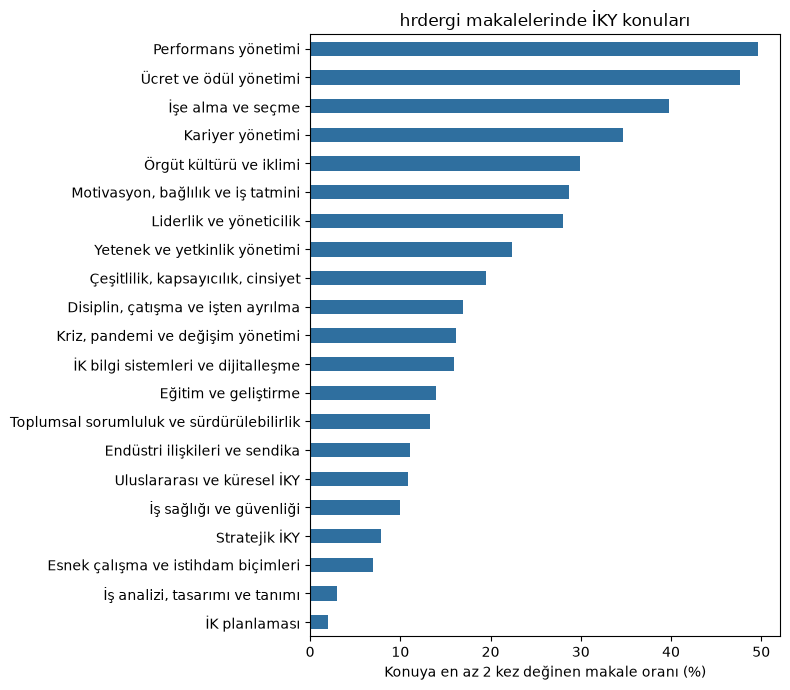

In [8]:
def count_patterns(text, pats):
    return sum(text.count(p) for p in pats)

M = pd.DataFrame({k: dfa["metin_temiz"].map(lambda t, p=pats: count_patterns(t, p)) for k, pats in THEME_PATTERNS.items()})
DENS = M.div(dfa["sozcuk_sayisi"], axis=0) * 1000
PRES = (M >= 2)           # en az 2 geçiş: tesadüfi anmayı ele
summary = pd.DataFrame({
    "makale_%": (PRES.mean() * 100).round(1),
    "ort_yoğunluk_/1000": DENS.mean().round(2),
    "toplam_geçiş": M.sum(),
}).sort_values("makale_%", ascending=False)
summary["ic_kitap_sayisi"] = toc_cov["kitap_sayisi"].reindex(summary.index)
display(summary)

fig, ax = plt.subplots(figsize=(8, 7))
summary["makale_%"].sort_values().plot.barh(ax=ax, color="#2f6f9f")
ax.set_xlabel("Konuya en az 2 kez değinen makale oranı (%)"); ax.set_title("hrdergi makalelerinde İKY konuları")
plt.tight_layout(); plt.savefig(f"{WORK_DIR}/konu_yayginligi.png", dpi=150); plt.show()

donem,≤2004,2005-09,2010-14,2015-19,2020-22,2023+
"İş analizi, tasarımı ve tanımı",5.400000,3.600000,2.400000,2.200000,1.600000,1.700000
İK planlaması,1.500000,2.200000,2.800000,1.600000,2.000000,2.000000
İşe alma ve seçme,31.400000,43.400000,46.600000,42.700000,41.100000,36.400000
Eğitim ve geliştirme,7.000000,18.700000,19.600000,14.400000,12.800000,13.500000
Performans yönetimi,42.400000,55.200000,58.600000,50.000000,44.400000,49.300000
Ücret ve ödül yönetimi,45.300000,49.000000,52.700000,47.600000,43.300000,49.300000
Kariyer yönetimi,29.000000,39.800000,44.500000,33.700000,27.900000,35.400000
Yetenek ve yetkinlik yönetimi,11.900000,27.800000,33.100000,26.200000,19.000000,19.500000
İş sağlığı ve güvenliği,7.300000,12.000000,7.100000,8.100000,8.900000,16.900000
Endüstri ilişkileri ve sendika,11.000000,14.200000,12.000000,12.400000,9.300000,7.400000


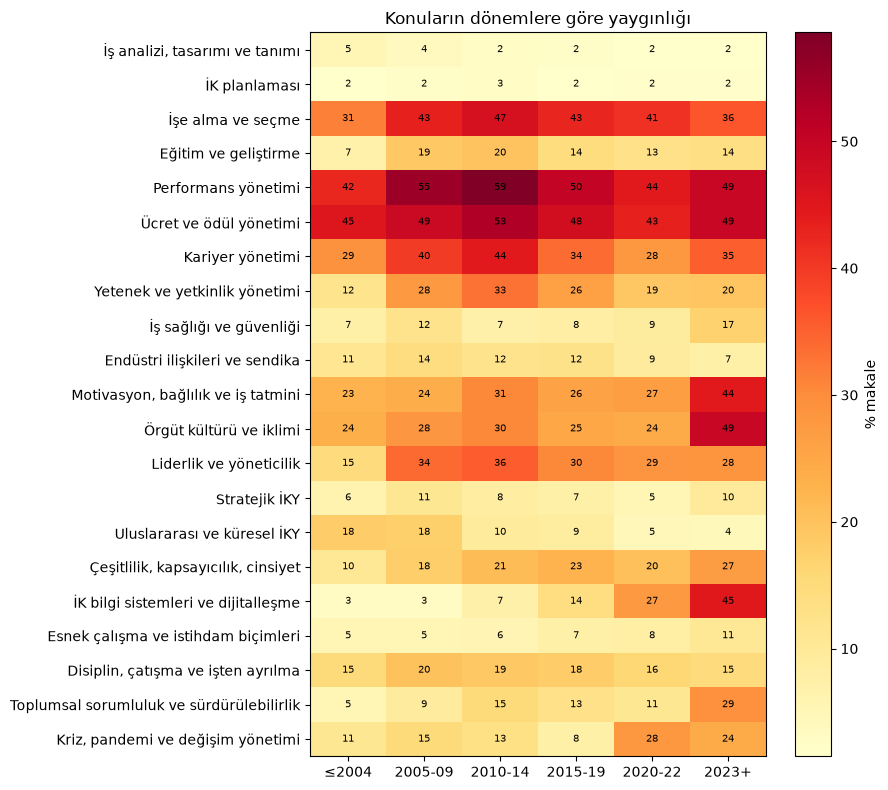

En çok düşen:


Uluslararası ve küresel İKY          -13.9
İş analizi, tasarımı ve tanımı        -3.7
Endüstri ilişkileri ve sendika        -3.6
Disiplin, çatışma ve işten ayrılma    -0.3
İK planlaması                          0.5
dtype: float64

En çok yükselen:


Çeşitlilik, kapsayıcılık, cinsiyet           16.3
Motivasyon, bağlılık ve iş tatmini           21.8
Toplumsal sorumluluk ve sürdürülebilirlik    23.9
Örgüt kültürü ve iklimi                      25.9
İK bilgi sistemleri ve dijitalleşme          41.7
dtype: float64

In [9]:
# Yıl / dönem kırılımı
dfa["donem"] = pd.cut(dfa["Yıl"].astype(float), bins=[1995, 2004, 2009, 2014, 2019, 2022, 2030],
                      labels=["≤2004", "2005-09", "2010-14", "2015-19", "2020-22", "2023+"])
byp = (PRES.groupby(dfa["donem"]).mean() * 100).T.round(1)
display(byp.style.background_gradient(cmap="YlOrRd", axis=1))

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(byp.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(byp.shape[1])); ax.set_xticklabels(byp.columns)
ax.set_yticks(range(byp.shape[0])); ax.set_yticklabels(byp.index)
for i in range(byp.shape[0]):
    for j in range(byp.shape[1]):
        ax.text(j, i, f"{byp.values[i,j]:.0f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, label="% makale"); ax.set_title("Konuların dönemlere göre yaygınlığı")
plt.tight_layout(); plt.savefig(f"{WORK_DIR}/konu_donem_isi_haritasi.png", dpi=150); plt.show()

# Yükselen / düşen konular: dönem ilk ↔ son fark
trend = (byp.iloc[:, -1] - byp.iloc[:, 0]).sort_values()
print("En çok düşen:"); display(trend.head(5).round(1))
print("En çok yükselen:"); display(trend.tail(5).round(1))

In [10]:
# Konsensüs (kitap) kavramlarının makalelerdeki frekansı
top_c = cons[(cons["n_sozcuk"] >= 2) & (cons["kitap_sayisi"] >= 2)].head(80)["kavram"].tolist()   # tek sözcükler fazla genel
big = " || ".join(dfa["metin_temiz"])
cons_freq = pd.DataFrame({"kavram": top_c,
                          "makalede_gecis": [big.count(c) for c in top_c],
                          "makale_sayisi": [int(dfa["metin_temiz"].str.contains(re.escape(c)).sum()) for c in top_c]})
cons_freq = cons_freq.merge(cons[["kavram", "kitap_sayisi"]], on="kavram").sort_values("makale_sayisi", ascending=False)
display(cons_freq.head(30))

,kavram,makalede_gecis,makale_sayisi,kitap_sayisi
2,performans değerlendirme,1716,608,4
21,kariyer planlama,581,309,3
46,dikkat edilmesi gereken,133,115,2
49,esnek çalışma saatleri,174,114,2
77,bilgi sistemleri,148,102,2
78,bilgi toplama,88,75,2
1,kariyer geliştirme,93,63,4
0,eğitim geliştirme,59,48,6
29,performans değerlendirmede,49,44,3
20,işçi sağlığı,62,33,3


## 6. İçindekiler başlıkları ↔ makaleler (TF-IDF kosinüs eşleştirme)

Her kitap başlığı bir "sorgu" sayılır; makalelerle kosinüs benzerliği hesaplanır.
Çıktılar: (i) başlık başına en yakın makale, (ii) bölüm/kitap düzeyinde dergi kapsamı, (iii) hiçbir başlığa benzemeyen makaleler (**kitap-dışı / yeni konular**).

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

def analyzer(doc):
    toks = [crude_stem(w) for w in doc.split() if len(w) > 2 and w not in STOP_ART]
    return toks + [a + "_" + b for a, b in zip(toks, toks[1:])]

vec = TfidfVectorizer(analyzer=analyzer, min_df=5, max_df=0.5, sublinear_tf=True)
X = vec.fit_transform(dfa["metin_temiz"])
Q = vec.transform(toc["baslik_norm"].map(prep))
print("Makale matrisi:", X.shape, "| Başlık matrisi:", Q.shape)

S = linear_kernel(Q, X)                       # başlık × makale
toc["en_yakin_sim"] = S.max(axis=1)
toc["en_yakin_makale"] = dfa["Makale Başlığı"].values[S.argmax(axis=1)]
THR = np.percentile(S[S > 0], 95)             # veri-güdümlü eşik
toc["eslesen_makale"] = (S >= THR).sum(axis=1)
print(f"Eşik (benzerlik) = {THR:.3f}")
display(toc.sort_values("eslesen_makale", ascending=False).head(20)[["kitap", "baslik", "eslesen_makale", "en_yakin_makale"]])

Makale matrisi: (3928, 150722) | Başlık matrisi: (1647, 150722)
Eşik (benzerlik) = 0.030


,kitap,baslik,eslesen_makale,en_yakin_makale
1507,"Stratejik İKY (Bayraktaroğlu-Atay, 2016)",İşe Alım,496,Uzaktan İşe Alımda İK'nın Rolü
722,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",Geri Bildirim,372,Geri bildirim sanatı: Daha iyi sonuçlar için yapıcı bir değerlendirme nasıl yapılır ve...
431,"İKY (Tüzüner vd., 2023, Beta)",İşveren Kavramı,358,İş Hayatında 'Ghosting' Kültürü: Çalışanlar ve İşverenler Neden Birbirini Yok Sayıyor?
952,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",İşveren Kavramı,358,İş Hayatında 'Ghosting' Kültürü: Çalışanlar ve İşverenler Neden Birbirini Yok Sayıyor?
862,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",Yetenek Yönetimi,355,Temel yeteneklerinizin farkında mısınız?
865,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",Yetenek Yönetimi Süreci,355,Temel yeteneklerinizin farkında mısınız?
1547,"Stratejik İKY (Bayraktaroğlu-Atay, 2016)",Yetenek Yönetimi,355,Temel yeteneklerinizin farkında mısınız?
357,"İKY (Tüzüner vd., 2023, Beta)",Toplu Ücretleme,316,"Bizim çaresizliğimiz; Büyük İstifa değil, Büyük Tükenmişlik"
225,"İKY (Tüzüner vd., 2023, Beta)",Geri-Bildirimin Kişiye Sunuluş Şekli,308,Geri bildirim sanatı: Daha iyi sonuçlar için yapıcı bir değerlendirme nasıl yapılır ve...
683,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",Teknoloji,301,Liderler için pandemi sonrası teknolojide manzara ne olacak?


In [12]:
cov = toc.groupby(["kitap", "bolum"]).agg(baslik=("baslik", "size"),
                                         ort_sim=("en_yakin_sim", "mean"),
                                         ort_eslesen=("eslesen_makale", "mean")).round(3)
display(cov.sort_values("ort_eslesen", ascending=False).head(15))
print("Dergide en az işlenen kitap başlıkları (ilgili makale çok az):")
display(toc[toc["en_yakin_sim"] > 0].sort_values("eslesen_makale").head(15)[["kitap", "baslik", "en_yakin_sim", "eslesen_makale"]])

# Hiçbir başlıkla eşleşmeyen makaleler
art_best = S.max(axis=0)
dfa["ic_en_yakin_sim"] = art_best
dfa["ic_en_yakin_baslik"] = toc["baslik"].values[S.argmax(axis=0)]
orphan = dfa.sort_values("ic_en_yakin_sim").head(25)[["Yıl", "Makale Başlığı", "ic_en_yakin_sim", "URL"]]
print("Kitap içindekilerine en az benzeyen makaleler (olası yeni/uç konular):")
display(orphan)

baslik  ort_sim  ort_eslesen
kitap                                    bolum                              
İKY ve Kariyer (Şimşek vd., 2016)        8           3    0.109      199.000
                                         9           6    0.072      154.167
İKY (Bakan, 2014, Gazi)                  9          27    0.104      124.778
İKY (Çetin-Dinç Elmalı-Arslan, 2019)     7          38    0.095      121.684
Stratejik İKY (Bayraktaroğlu-Atay, 2016) 7          16    0.097      109.250
İKY ve Kariyer (Şimşek vd., 2016)        2           5    0.073      105.400
İKY (Bakan, 2014, Gazi)                  13          9    0.086      104.333
İKY (Saruhan-Yıldız, 2019, Beta)         5           8    0.067      103.250
İKY (Tüzüner vd., 2023, Beta)            6          16    0.088      102.500
Stratejik İKY (Bayraktaroğlu-Atay, 2016) 1          13    0.083       90.692
İKY (Çetin-Dinç Elmalı-Arslan, 2019)     10          5    0.193       89.600
İKY (Bakan, 2014, Gazi)                  8          20    0.086       88.850
                                         16         15    0.100       84.600
İKY ve Kariyer (Şimşek vd., 2016)        4          13    0.072       84.077
Stratejik İKY (Bayraktaroğlu-Atay, 2016) 5          25    0.095       83.040

Dergide en az işlenen kitap başlıkları (ilgili makale çok az):


,kitap,baslik,en_yakin_sim,eslesen_makale
627,"İKY (Tüzüner vd., 2023, Beta)",Grevin Başlatılması ve Uygulanması (STİSK md. 64),0.060961,2
933,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",Gantt Ücret Sistemi,0.032034,2
1030,"İKY (Bakan, 2014, Gazi)",İNSAN KAYNAKLARININ İŞLETME SİSTEMİ İÇERİSİNDEKİ ÖNEMİ VE,0.068578,4
1614,"İKY ve Kariyer (Şimşek vd., 2016)",KARİYERLE İLGİLİ KONULARIN KAVRAMSAL TEMELLERİ,0.040126,4
884,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",Karşılaştırma Yöntemi,0.108382,4
1117,"İKY (Bakan, 2014, Gazi)",İŞ ŞARTNAMESİ,0.094172,4
818,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",Teknoloji Temelli Eğitim Yöntemleri,0.101230,4
176,"İKY (Tüzüner vd., 2023, Beta)",Deney-Kontrol Grubu Yöntemi,0.086712,4
708,"İKY (Çetin-Dinç Elmalı-Arslan, 2019)",İş Gerekleri (İş Şartnamesi),0.094172,4
1461,"Stratejik İKY (Bayraktaroğlu-Atay, 2016)",Strateji Kurulumunda Önemli Noktalar,0.037240,4


Kitap içindekilerine en az benzeyen makaleler (olası yeni/uç konular):


,Yıl,Makale Başlığı,ic_en_yakin_sim,URL
3249,2022,Konfor alanınızdan çıkmadan parlayamazsınız!,0.022327,https://hrdergi.com/konfor-alaninizdan-cikmadan-parlayamazsiniz
2065,2015,Kurumsal Kaşif: İK’cı... Çalışanların fikirlerindeki kilitleri açmak için İK’cı ne ya...,0.023513,https://hrdergi.com/kurumsal-kasif-ik-ci-calisanlarin-fikirlerindeki-kilitleri-acmak-i...
2970,2021,Kurumsal iş yapış tarzını yenileme zamanı,0.023832,https://hrdergi.com/kurumsal-is-yapis-tarzini-yenileme-zamani
2545,2019,Yeni dünyada insana ve İK’ya tavsiye: Günü yakalayın ve zorlayıcı bir farklılık yaratın!,0.023993,https://hrdergi.com/yeni-dunyada-insana-ve-ik-ya-tavsiye-gunu-yakalayin-ve-zorlayici-b...
1520,2010,Yıldız avcısı İK için yıldız olma zamanı gelmedi mi? Tüm mesele; yıldızın yıldız bulma...,0.024010,https://hrdergi.com/yildiz-avcisi-ik-icin-yildiz-olma-zamani-gelmedi-mi-tum-mesele-yil...
2197,2016,Şirketin ve çalışanın yetenek yönetimi birbirinden farklı mıdır?,0.024190,https://hrdergi.com/sirketin-ve-calisanin-yetenek-yonetimi-birbirinden-farkli-midir
3017,2021,Liderlerin kültür ve kimlik kavramını neden bilmesi gerekir?,0.024212,https://hrdergi.com/liderlerin-kultur-ve-kimlik-kavramini-neden-bilmesi-gerekir
2295,2017,Bir şirkette yaratıcı ve esinlendirici fikirler nasıl çıkar? Yetenek ve yaratıcılık ar...,0.024272,https://hrdergi.com/bir-sirkette-yaratici-ve-esinlendirici-fikirler-nasil-cikar-yetene...
1614,2011,Liderlik üzerine kurulmuş ailevi fanteziler ve tuzaklar Size baba diyebilir miyim?,0.024770,https://hrdergi.com/liderlik-uzerine-kurulmus-ailevi-fanteziler-ve-tuzaklar-size-baba-...
1567,2011,Liderliğin tescili: Kültür-organizasyon-karar verme ''Lideri yöneticiden ayıran üç güç...,0.027354,https://hrdergi.com/liderligin-tescili-kultur-organizasyon-karar-verme-lideri-yonetici...


## 7. Denetimsiz konu modeli (NMF) ve İÇ konularıyla karşılaştırma

,konu,en_belirgin_sozcukler,makale_payi_%
0,0,"benim, bana, diye, beni, düşünüyorum, biraz, oldu, böyle, başladım, belki",8.8
1,1,"çalışanlarımızın, çalışanlarımız, çalışanlarımıza, bizim, gelişim, çalışıyoruz, hayata...",13.0
2,2,"yapay, dijital, zekâ, esnek, uzaktan, dünyasında, teşvik, çeşitlilik, veri, sürdürüleb...",9.6
3,3,"yalnızca, sessiz, duygusal, kurumun, görünür, görünmeyen, kurumların, görünmez, kurums...",4.5
4,4,"zirvede, başlıklı, paylaştı, müdürü, belirtti, isim, çizdi, konuşmasında, belirten, zi...",4.8
5,5,"işçinin, işverenin, kanunu, işveren, işçi, sayılı, halinde, sözleşmesi, işyerinde, fesih",2.6
6,6,"şehir, şehrin, tarihi, muhteşem, güzel, ziyaret, şehri, sahipliği, ederim, müzesi",3.3
7,7,"tepe, ticari, yöneticiler, müşteri, yöneticilerin, stratejik, finansal, satış, karşın,...",9.4
8,8,"sizin, olun, edin, size, unutmayın, vardır, insanlar, kişiler, asla, genellikle",14.3
9,9,"aday, adayın, alım, adayların, değerlendirme, adaylar, mülakat, yöntemlerinin, araştır...",2.3


,nmf_konu,en_yakin_ic_konusu,lift,en_belirgin_sozcukler
0,0,"Çeşitlilik, kapsayıcılık, cinsiyet",1.14,"benim, bana, diye, beni, düşünüyorum, biraz, oldu, böyle, başladım, belki"
1,1,Toplumsal sorumluluk ve sürdürülebilirlik,2.05,"çalışanlarımızın, çalışanlarımız, çalışanlarımıza, bizim, gelişim, çalışıyoruz, hayata..."
2,2,İK bilgi sistemleri ve dijitalleşme,5.87,"yapay, dijital, zekâ, esnek, uzaktan, dünyasında, teşvik, çeşitlilik, veri, sürdürüleb..."
3,3,"Kriz, pandemi ve değişim yönetimi",3.31,"yalnızca, sessiz, duygusal, kurumun, görünür, görünmeyen, kurumların, görünmez, kurums..."
4,4,Uluslararası ve küresel İKY,2.65,"zirvede, başlıklı, paylaştı, müdürü, belirtti, isim, çizdi, konuşmasında, belirten, zi..."
5,5,Endüstri ilişkileri ve sendika,9.32,"işçinin, işverenin, kanunu, işveren, işçi, sayılı, halinde, sözleşmesi, işyerinde, fesih"
6,6,"Çeşitlilik, kapsayıcılık, cinsiyet",1.05,"şehir, şehrin, tarihi, muhteşem, güzel, ziyaret, şehri, sahipliği, ederim, müzesi"
7,7,Stratejik İKY,3.46,"tepe, ticari, yöneticiler, müşteri, yöneticilerin, stratejik, finansal, satış, karşın,..."
8,8,Liderlik ve yöneticilik,1.79,"sizin, olun, edin, size, unutmayın, vardır, insanlar, kişiler, asla, genellikle"
9,9,İşe alma ve seçme,11.03,"aday, adayın, alım, adayların, değerlendirme, adaylar, mülakat, yöntemlerinin, araştır..."


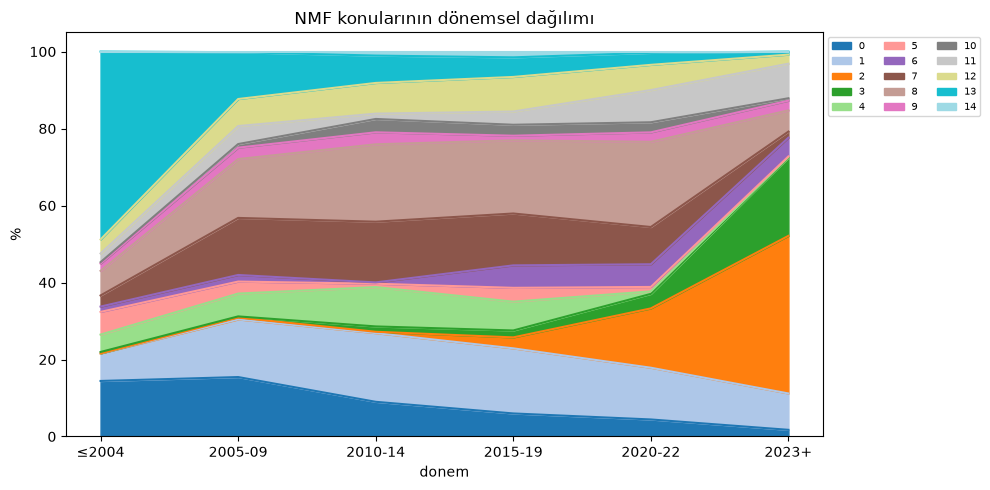

In [13]:
from sklearn.decomposition import NMF
K = 15
vec2 = TfidfVectorizer(analyzer=lambda d: [w for w in d.split() if len(w) > 3 and w not in STOP_ART],
                       min_df=10, max_df=0.4, sublinear_tf=True, max_features=15000)
X2 = vec2.fit_transform(dfa["metin_temiz"])
nmf = NMF(n_components=K, init="nndsvda", random_state=42, max_iter=400)
W = nmf.fit_transform(X2)
terms = np.array(vec2.get_feature_names_out())
tinfo = pd.DataFrame({
    "konu": range(K),
    "en_belirgin_sozcukler": [", ".join(terms[nmf.components_[k].argsort()[::-1][:10]]) for k in range(K)],
    "makale_payi_%": (np.bincount(W.argmax(axis=1), minlength=K) / len(W) * 100).round(1),
})
display(tinfo)

# NMF konusu ↔ İÇ konusu: ortalama yoğunluk korelasyonu
dfa["nmf_konu"] = W.argmax(axis=1)
cmp_ = DENS.groupby(dfa["nmf_konu"]).mean() / DENS.mean()      # genel ortalamaya oranla (lift)
best = pd.DataFrame({"nmf_konu": cmp_.index,
                     "en_yakin_ic_konusu": cmp_.idxmax(axis=1).values,
                     "lift": cmp_.max(axis=1).round(2).values})
display(best.merge(tinfo[["konu", "en_belirgin_sozcukler"]], left_on="nmf_konu", right_on="konu").drop(columns="konu"))

# NMF konularının yıllara göre seyri
tp = pd.crosstab(dfa["donem"], dfa["nmf_konu"], normalize="index") * 100
ax = tp.plot(kind="area", stacked=True, figsize=(10, 5), colormap="tab20")
ax.set_ylabel("%"); ax.set_title("NMF konularının dönemsel dağılımı"); ax.legend(ncol=3, fontsize=7, bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.savefig(f"{WORK_DIR}/nmf_donem.png", dpi=150); plt.show()

## 8. En sık sözcükler ve dışa aktarım

In [14]:
# Yıllara göre en ayırt edici sözcükler (dönem başına TF-IDF toplamı)
top = pd.DataFrame({str(d): np.asarray(X2[(dfa["donem"] == d).values].mean(axis=0)).ravel()
                    for d in dfa["donem"].cat.categories}, index=terms)
for d in top.columns:
    print(d, "->", ", ".join(top[d].sort_values(ascending=False).head(12).index))

≤2004 -> hizmet, müşteri, bütün, kalite, gerekli, istanbul, açısından, kişi, bizim, önem, yönetici, personel
2005-09 -> yönetici, kişi, ardından, neler, sıra, kişinin, görev, yanı, biraz, biçimde, oldu, gelişim
2010-14 -> yetenek, yönetici, gelişim, oldu, liderlik, gerçekten, kariyer, değerlendirme, onların, stratejik, genellikle, organizasyonun
2015-19 -> yetenek, gelişim, genellikle, organizasyonun, liderlik, oldu, hayata, biçimde, organizasyon, değildir, yönetici, kurumsal
2020-22 -> pandemi, uzaktan, birçok, genellikle, sosyal, yetenek, liderlik, güçlü, çalışanları, alım, insanlar, yeniden
2023+ -> etiketler, yalnızca, yapay, zekâ, dijital, dünyasında, duygusal, birçok, sürdürülebilir, teşvik, kritik, gelişim


In [15]:
out = f"{WORK_DIR}/hrdergi_icindekiler_analiz.xlsx"
with pd.ExcelWriter(out) as xw:
    toc.drop(columns=["baslik_norm"]).to_excel(xw, sheet_name="IC_basliklar", index=False)
    toc_cov.to_excel(xw, sheet_name="IC_konu_dogrulama")
    cons.to_excel(xw, sheet_name="konsensus_kavramlar", index=False)
    summary.to_excel(xw, sheet_name="konu_yayginligi")
    byp.to_excel(xw, sheet_name="konu_donem")
    cons_freq.to_excel(xw, sheet_name="kavram_frekans", index=False)
    cov.to_excel(xw, sheet_name="bolum_kapsam")
    orphan.to_excel(xw, sheet_name="kitap_disi_makaleler", index=False)
    tinfo.to_excel(xw, sheet_name="nmf_konular", index=False)
    dfa.drop(columns=[TEXT, "metin_temiz"]).to_excel(xw, sheet_name="makale_ozet", index=False)
print("Yazıldı:", out)

Yazıldı: work/hrdergi_icindekiler_analiz.xlsx


## Yorum için kontrol listesi
* **Sözlük geçerliği:** `toc_cov` tablosunda hiç/az kitapta geçen konular için anahtar ifadeleri gözden geçirin.
* **Eşik:** `THR` %95 yüzdeliğidir; daha sıkı sonuç için %98 deneyin.
* **Kökleme:** F5 (ilk 5 harf) kaba bir yöntemdir; `zeyrek`/`snowballstemmer` ile değiştirilebilir.
* **Doğrulama:** Konu atamalarını rastgele 30 makalede elle kontrol edip kesinlik oranı raporlayın.
* **Dengesizlik:** Makale sayısı yıllara eşit dağılmaz (bkz. bölüm 1); dönemler arası karşılaştırmada yüzdeleri kullanın.